# Two-Stage Hierarchical Readability Model (BiLSTM + Ordinal-Aware)
#
# **Strategy**: Decompose the 6-level problem into two stages:
#
# | Stage | Task | Classes |
# |-------|------|---------|
# | 1 — Coarse | easy vs hard | 2 |
# | 2 — Fine | sub-level within group | 3 each |
#
# **Group mapping**:  easy = {0,1,2},  hard = {3,4,5}
#
# Binary coarse split should be very accurate, and each fine model
# only distinguishes 3 nearby levels.


In [1]:
!pip install -q transformers datasets scikit-learn torch joblib

In [2]:
import os, random, joblib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, cohen_kappa_score,
                             top_k_accuracy_score, f1_score)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

In [3]:
print("=" * 50)
print("GPU CHECK")
print("=" * 50)
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count:   {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name:    {torch.cuda.get_device_name(0)}")
    print(f"CUDA version:   {torch.version.cuda}")
else:
    print("WARNING: No GPU detected!")
print("=" * 50)

GPU CHECK
CUDA available: True
Device count:   1
Current device: 0
Device name:    Tesla P100-PCIE-16GB
CUDA version:   12.6


In [4]:
# =====================================================================
# CONFIGURATION
# =====================================================================

# Data paths — update if your CSV lives elsewhere
DATA_CSV = "/kaggle/input/datasets/feryaljadallah/refinedbayyin/Refined_Bayyin_Dataset.csv"
TEXT_COL = "Sentence"
LABEL_COL = "Readability_Level"
ID_COL = "ID"

# D3Tok is the primary static feature
D3TOK_COL = "D3Tok"

# Extra numeric and categorical metadata columns
NUMERIC_COLS = ["Word_Count", "Word", "Lex", "D3Lex"]
CATEGORICAL_COLS = ["Document", "Source", "Book", "Author", "Domain",
                    "Text_Class", "Dataset_Source"]

# Shared training hyper-parameters
BATCH_SIZE = 64
NUM_CLASSES = 6          # original fine-grained count
LSTM_HIDDEN = 256
DROPOUT = 0.4
WEIGHT_DECAY = 1e-2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
OUTPUT_DIR = "./hierarchical_bilstm"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Transformer configs
CAMELBERT_MODEL = "CAMeL-Lab/bert-base-arabic-camelbert-msa"
MAX_LEN = 128

# Partial freeze — unfreeze last N BERT encoder layers
UNFREEZE_LAST_N = 6

# Learning rates (differential)
BERT_LR = 2e-5
HEAD_LR = 5e-4
STATIC_LR = 1e-3

# Ordinal loss knob (used at each stage with fewer classes)
ORDINAL_LAMBDA = 0.4

# Per-stage epoch budgets and patience
COARSE_EPOCHS = 12       # stage 1 can converge fast (only 3 classes)
FINE_EPOCHS = 10          # stage 2 is a binary-ish split
PATIENCE = 3

# ── Hierarchical grouping ──
# Stage 1: binary split (easy vs hard)
# Stage 2: 3-class within each group
COARSE_MAP = {0: 0, 1: 0, 2: 0,   # easy
              3: 1, 4: 1, 5: 1}   # hard
COARSE_NAMES = ["easy", "hard"]
NUM_COARSE = 2

# Within each coarse group, fine labels remap to 0/1/2
FINE_GROUPS = {
    0: {"labels": [0, 1, 2], "remap": {0: 0, 1: 1, 2: 2}},  # easy
    1: {"labels": [3, 4, 5], "remap": {3: 0, 4: 1, 5: 2}},  # hard
}
NUM_FINE = 3  # each sub-classifier is 3-class

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def normalize_arabic(text):
    """Basic Arabic normalisation (hamza, ya, diacritics)."""
    if not isinstance(text, str):
        return ""
    import re
    text = text.replace("أ", "ا").replace("إ", "ا").replace("آ", "ا")
    text = text.replace("ى", "ي")
    text = re.sub("[ً-ْـ]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [6]:
set_seed(SEED)

# Load data
df = pd.read_csv(DATA_CSV)
df[TEXT_COL] = df[TEXT_COL].astype(str).apply(normalize_arabic)

# Shift labels to 0-5 if they start at 1
if df[LABEL_COL].min() == 1:
    df[LABEL_COL] = df[LABEL_COL] - 1
assert df[LABEL_COL].min() >= 0 and df[LABEL_COL].max() < NUM_CLASSES

# Build coarse labels from the fine ones
df["Coarse_Label"] = df[LABEL_COL].map(COARSE_MAP)

# Scale D3Tok
df[D3TOK_COL] = pd.to_numeric(df[D3TOK_COL], errors="coerce").fillna(0.0)
d3tok_scaler = StandardScaler()
df[D3TOK_COL] = d3tok_scaler.fit_transform(df[[D3TOK_COL]])

# Scale numeric metadata
for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df[NUMERIC_COLS] = df[NUMERIC_COLS].fillna(0.0)
meta_scaler = StandardScaler()
df[NUMERIC_COLS] = meta_scaler.fit_transform(df[NUMERIC_COLS])

# Encode categoricals
label_encoders = {}
for c in CATEGORICAL_COLS:
    df[c] = df[c].fillna("UNKNOWN").astype(str)
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c])
    label_encoders[c] = le

# Save preprocessing artefacts
joblib.dump({"d3tok_scaler": d3tok_scaler, "meta_scaler": meta_scaler,
             "label_encoders": label_encoders},
            os.path.join(OUTPUT_DIR, "meta_encoders.joblib"))

# Stratified split on the FINE label (preserves coarse distribution too)
train_val_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df[LABEL_COL], random_state=SEED)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.125, stratify=train_val_df[LABEL_COL], random_state=SEED)

print(f"Split ratios -> Train: {len(train_df)/len(df):.0%}, Val: {len(val_df)/len(df):.0%}, Test: {len(test_df)/len(df):.0%}")
print(f"Train: {len(train_df)},  Val: {len(val_df)},  Test: {len(test_df)}")
print(f"Coarse distribution (train):")
print(train_df["Coarse_Label"].value_counts().sort_index().to_dict())

Split ratios -> Train: 70%, Val: 10%, Test: 20%
Train: 31441,  Val: 4492,  Test: 8984
Coarse distribution (train):
{0: 15512, 1: 15929}


In [7]:
# D3Tok arrays not needed — using CamelBERT only


In [8]:
print("Loading CamelBERT tokenizer...")
camelbert_tokenizer = AutoTokenizer.from_pretrained(CAMELBERT_MODEL, use_fast=True)


Loading CamelBERT tokenizer...


config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [9]:
class OrdinalAwareLoss(nn.Module):
    """
    Ordinal-aware loss: weighted CE + KL ordinal distance penalty.
    Works for any number of classes (3 for coarse, 2 for fine, 6 for flat).
    """
    def __init__(self, num_classes, ordinal_lambda=0.4, sigma=2.0):
        super().__init__()
        self.num_classes = num_classes
        self.ordinal_lambda = ordinal_lambda
        self.sigma = sigma

    def forward(self, logits, labels):
        probs = torch.softmax(logits, dim=-1)

        # Hard-example weighting
        true_probs = probs.gather(1, labels.unsqueeze(1)).squeeze(1)
        difficulty = (1.0 - true_probs.detach()) + 0.5
        difficulty = difficulty / difficulty.mean()

        # Ordinal soft targets (Gaussian centred on true label)
        K = logits.shape[-1]
        indices = torch.arange(K, dtype=torch.float32, device=logits.device)
        dist = torch.abs(indices - labels.float().unsqueeze(1))
        soft = torch.exp(-dist / self.sigma)
        soft = soft / soft.sum(dim=1, keepdim=True)

        # Weighted CE
        ce = F.cross_entropy(logits, labels, reduction="none")
        weighted_ce = ce * difficulty

        # KL ordinal regulariser
        log_p = F.log_softmax(logits, dim=-1)
        kl = F.kl_div(log_p, soft, reduction="none").sum(dim=1)

        return (weighted_ce + self.ordinal_lambda * kl).mean()


print("OrdinalAwareLoss ready (works for any K).")

OrdinalAwareLoss ready (works for any K).


In [10]:
class StaticEmbeddingDataset(Dataset):
    """Dataset for static features (D3Tok)."""
    def __init__(self, embeddings, df, label_col, numeric_cols, categorical_cols):
        self.embeddings = embeddings
        self.labels = df[label_col].astype(int).values
        self.numeric = df[numeric_cols].values.astype(np.float32)
        self.categorical = df[categorical_cols].values.astype(np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "embedding": torch.tensor(self.embeddings[idx], dtype=torch.float32),
            "numeric":   torch.tensor(self.numeric[idx],    dtype=torch.float32),
            "categorical": torch.tensor(self.categorical[idx], dtype=torch.long),
            "label":     torch.tensor(self.labels[idx],     dtype=torch.long),
        }


class TransformerDataset(Dataset):
    """Dataset for BERT-based models (partial fine-tune)."""
    def __init__(self, df, tokenizer, text_col, label_col,
                 numeric_cols, categorical_cols, max_len):
        self.texts = df[text_col].values
        self.labels = df[label_col].astype(int).values
        self.numeric = df[numeric_cols].values.astype(np.float32)
        self.categorical = df[categorical_cols].values.astype(np.int64)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], padding="max_length",
                             truncation=True, max_length=self.max_len,
                             return_tensors="pt")
        return {
            "input_ids":     enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "numeric":       torch.tensor(self.numeric[idx],     dtype=torch.float32),
            "categorical":   torch.tensor(self.categorical[idx], dtype=torch.long),
            "label":         torch.tensor(self.labels[idx],      dtype=torch.long),
        }

In [11]:
def freeze_bert_except_last_n(bert_model, n=2):
    """Freeze all BERT params except the last n encoder layers + pooler."""
    for param in bert_model.parameters():
        param.requires_grad = False
    num_layers = len(bert_model.encoder.layer)
    for i in range(max(0, num_layers - n), num_layers):
        for param in bert_model.encoder.layer[i].parameters():
            param.requires_grad = True
    if hasattr(bert_model, "pooler") and bert_model.pooler is not None:
        for param in bert_model.pooler.parameters():
            param.requires_grad = True
    frozen_p = sum(p.numel() for p in bert_model.parameters() if not p.requires_grad)
    train_p  = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
    print(f"  BERT freeze: {frozen_p:,} frozen | {train_p:,} trainable | last {n}/{num_layers} unfrozen")


class AttentionPooling(nn.Module):
    """Learned attention pooling over a sequence."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out, mask=None):
        scores = self.attn(lstm_out).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        return (lstm_out * weights).sum(dim=1)


class BiLSTMWithMeta(nn.Module):
    """
    BiLSTM classifier with metadata — reused for both stages.
    The only thing that changes between stages is `num_classes`.
    """
    def __init__(self, input_dim, categorical_cardinalities, num_numeric,
                 lstm_hidden=256, lstm_layers=2, meta_proj_dim=128,
                 num_classes=3, dropout=0.3,
                 use_bert=False, bert_model_name=None, unfreeze_last_n=2):
        super().__init__()
        self.use_bert = use_bert
        self.num_classes = num_classes

        if use_bert and bert_model_name:
            self.bert = AutoModel.from_pretrained(bert_model_name)
            freeze_bert_except_last_n(self.bert, n=unfreeze_last_n)
            input_dim = self.bert.config.hidden_size
        else:
            self.bert = None

        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=lstm_hidden,
                            num_layers=lstm_layers, batch_first=True,
                            bidirectional=True,
                            dropout=dropout if lstm_layers > 1 else 0.0)

        self.attn_pool = AttentionPooling(lstm_hidden * 2)

        # Categorical embeddings
        self.cat_names = list(categorical_cardinalities.keys())
        self.cat_embeddings = nn.ModuleDict()
        total_cat_dim = 0
        for name, card in categorical_cardinalities.items():
            emb_dim = min(50, max(4, int(card ** 0.5)))
            self.cat_embeddings[name] = nn.Embedding(card, emb_dim)
            total_cat_dim += emb_dim

        self.meta_proj = nn.Sequential(
            nn.Linear(total_cat_dim + num_numeric, meta_proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2 + meta_proj_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, numeric_meta, categorical_meta, attention_mask=None):
        if self.use_bert:
            x = self.bert(input_ids=x, attention_mask=attention_mask).last_hidden_state
        else:
            if len(x.shape) == 2:
                x = x.unsqueeze(1)

        lstm_out, _ = self.lstm(x)
        pooled = self.attn_pool(lstm_out, mask=attention_mask if self.use_bert else None)

        cat_embs = [self.cat_embeddings[name](categorical_meta[:, i])
                    for i, name in enumerate(self.cat_names)]
        cat_concat = torch.cat(cat_embs, dim=1) if cat_embs else \
                     torch.zeros(numeric_meta.size(0), 0, device=numeric_meta.device)
        meta_vec = self.meta_proj(torch.cat([numeric_meta, cat_concat], dim=1))

        fused = self.dropout(torch.cat([pooled, meta_vec], dim=1))
        return self.classifier(fused)

In [12]:
def train_epoch(model, loader, optimizer, scheduler, device,
                is_transformer, num_classes):
    model.train()
    criterion = OrdinalAwareLoss(num_classes=num_classes, ordinal_lambda=ORDINAL_LAMBDA)
    total_loss = 0.0
    all_preds, all_trues = [], []

    for batch in loader:
        if is_transformer:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            logits = model(ids, batch["numeric"].to(device),
                           batch["categorical"].to(device), mask)
        else:
            emb = batch["embedding"].to(device)
            logits = model(emb, batch["numeric"].to(device),
                           batch["categorical"].to(device))

        labels = batch["label"].to(device)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        all_preds += logits.detach().cpu().argmax(dim=1).tolist()
        all_trues += labels.cpu().tolist()

    return total_loss / len(loader.dataset), accuracy_score(all_trues, all_preds)


def eval_model(model, loader, device, is_transformer, num_classes):
    model.eval()
    criterion = OrdinalAwareLoss(num_classes=num_classes, ordinal_lambda=ORDINAL_LAMBDA)
    total_loss = 0.0
    all_preds, all_trues, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            if is_transformer:
                ids  = batch["input_ids"].to(device)
                mask = batch["attention_mask"].to(device)
                logits = model(ids, batch["numeric"].to(device),
                               batch["categorical"].to(device), mask)
            else:
                emb = batch["embedding"].to(device)
                logits = model(emb, batch["numeric"].to(device),
                               batch["categorical"].to(device))

            labels = batch["label"].to(device)
            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)

            probs = torch.softmax(logits, dim=-1).cpu()
            all_preds += logits.cpu().argmax(dim=1).tolist()
            all_trues += labels.cpu().tolist()
            all_probs += probs.tolist()

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_trues, all_preds)
    return avg_loss, acc, all_trues, all_preds, all_probs

In [13]:
def _to_cpu_state_dict(sd):
    return {k: v.cpu() if hasattr(v, 'cpu') else v for k, v in sd.items()}


def _build_model(input_dim, num_classes, is_transformer, bert_model_name):
    """Convenience: build a BiLSTMWithMeta with the right num_classes."""
    cat_card = {c: int(df[c].max()) + 1 for c in CATEGORICAL_COLS}
    return BiLSTMWithMeta(
        input_dim=input_dim,
        categorical_cardinalities=cat_card,
        num_numeric=len(NUMERIC_COLS),
        lstm_hidden=LSTM_HIDDEN,
        meta_proj_dim=128,
        num_classes=num_classes,
        dropout=DROPOUT,
        use_bert=is_transformer,
        bert_model_name=bert_model_name,
        unfreeze_last_n=UNFREEZE_LAST_N,
    ).to(DEVICE)

In [14]:
def train_single_stage(tag, model, train_loader, val_loader,
                       is_transformer, num_classes, epochs, lr_config):
    """
    Train one model (coarse or fine) with early stopping.
    lr_config is a dict: {'bert_lr', 'head_lr'} for transformer,
    or {'static_lr'} for static.
    Returns best checkpoint path.
    """
    print(f"\n--- Training [{tag}]  classes={num_classes}  epochs={epochs} ---")
    total_params = sum(p.numel() for p in model.parameters())
    train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Params: {total_params:,} total, {train_params:,} trainable")

    # Optimizer
    if is_transformer:
        no_decay = ["bias", "LayerNorm.weight"]
        bert_d  = [p for n, p in model.bert.named_parameters()
                   if p.requires_grad and not any(nd in n for nd in no_decay)]
        bert_nd = [p for n, p in model.bert.named_parameters()
                   if p.requires_grad and any(nd in n for nd in no_decay)]
        head_p  = [p for n, p in model.named_parameters() if not n.startswith("bert.")]
        groups = [
            {"params": bert_d,  "weight_decay": WEIGHT_DECAY, "lr": lr_config["bert_lr"]},
            {"params": bert_nd, "weight_decay": 0.0,          "lr": lr_config["bert_lr"]},
            {"params": head_p,  "weight_decay": WEIGHT_DECAY, "lr": lr_config["head_lr"]},
        ]
        optimizer = AdamW(groups, eps=1e-8)
    else:
        optimizer = AdamW(model.parameters(), lr=lr_config["static_lr"],
                          weight_decay=WEIGHT_DECAY)

    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(0.10 * total_steps)),
        num_training_steps=total_steps,
    )

    best_val_acc = 0.0
    ckpt_path = os.path.join(OUTPUT_DIR, f"best_{tag}.pt")
    patience_ctr = 0
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer,
                                      scheduler, DEVICE, is_transformer,
                                      num_classes)
        vl_loss, vl_acc, _, _, _ = eval_model(model, val_loader, DEVICE,
                                              is_transformer, num_classes)
        elapsed = (time.time() - t0) / 60
        print(f"  Ep {epoch:02d} | trn {tr_loss:.4f}/{tr_acc:.4f} "
              f"| val {vl_loss:.4f}/{vl_acc:.4f} | {elapsed:.1f}m")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(_to_cpu_state_dict(model.state_dict()), ckpt_path)
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"  Early stop at epoch {epoch}")
                break

    print(f"  Best val acc: {best_val_acc:.4f}")
    # Reload best weights
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    return ckpt_path, best_val_acc, (time.time() - t0) / 60

In [15]:
def run_hierarchical(embedding_name, train_data, val_data, test_data,
                     input_dim, is_transformer=False, bert_model_name=None):
    """
    Full two-stage hierarchical pipeline for one embedding type.
    """
    print(f"\n{'=' * 65}")
    print(f"HIERARCHICAL MODEL: {embedding_name.upper()}")
    print(f"{'=' * 65}")

    # ── Helper to pick the right tokenizer ──
    tokenizer = None
    if is_transformer:
        tokenizer = camelbert_tokenizer

    # ── Build datasets with COARSE labels for stage 1 ──
    def make_ds(split_df, emb_data, label_col):
        if is_transformer:
            return TransformerDataset(split_df, tokenizer, TEXT_COL, label_col,
                                     NUMERIC_COLS, CATEGORICAL_COLS, MAX_LEN)
        else:
            return StaticEmbeddingDataset(emb_data, split_df, label_col,
                                         NUMERIC_COLS, CATEGORICAL_COLS)

    # Stage 1 datasets (coarse labels)
    coarse_train_ds = make_ds(train_df, train_data, "Coarse_Label")
    coarse_val_ds   = make_ds(val_df,   val_data,   "Coarse_Label")
    coarse_test_ds  = make_ds(test_df,  test_data,  "Coarse_Label")

    coarse_train_loader = DataLoader(coarse_train_ds, batch_size=BATCH_SIZE, shuffle=True)
    coarse_val_loader   = DataLoader(coarse_val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    coarse_test_loader  = DataLoader(coarse_test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    # ================================================================
    # STAGE 1 — Coarse classifier (3 classes)
    # ================================================================
    print(f"\n>>> STAGE 1: Coarse classifier (easy / medium / hard)")
    coarse_model = _build_model(input_dim, NUM_COARSE, is_transformer, bert_model_name)

    lr_cfg = ({"bert_lr": BERT_LR, "head_lr": HEAD_LR} if is_transformer
              else {"static_lr": STATIC_LR})
    coarse_ckpt, coarse_best_val, coarse_time = train_single_stage(
        f"{embedding_name}_coarse", coarse_model,
        coarse_train_loader, coarse_val_loader,
        is_transformer, NUM_COARSE, COARSE_EPOCHS, lr_cfg,
    )

    # Evaluate coarse on test
    _, coarse_test_acc, c_true, c_pred, c_probs = eval_model(
        coarse_model, coarse_test_loader, DEVICE, is_transformer, NUM_COARSE)
    print(f"  Coarse test acc: {coarse_test_acc:.4f}")

    # INDENT THESE LINES[cite: 1]
    from sklearn.metrics import f1_score, cohen_kappa_score
    coarse_wf1 = f1_score(c_true, c_pred, average='weighted')
    coarse_qwk = cohen_kappa_score(c_true, c_pred, weights="quadratic")

    print(f"  Coarse Weighted F1: {coarse_wf1:.4f}") 
    print(f"  Coarse QWK:         {coarse_qwk:.4f}") 

    # Free GPU if transformer (we'll reload per fine stage)
    if is_transformer:
        del coarse_model
        torch.cuda.empty_cache()

    # ================================================================
    # STAGE 2 — Fine classifiers (one per coarse group, 2 classes each)
    # ================================================================
    fine_models_ckpt = {}
    fine_times = {}

    for g_idx, g_info in FINE_GROUPS.items():
        g_name = COARSE_NAMES[g_idx]
        orig_labels = g_info["labels"]
        remap = g_info["remap"]
        print(f"\n>>> STAGE 2-{g_name}: Fine classifier for group {g_idx} "
              f"(labels {orig_labels})")

        g_train = train_df[train_df[LABEL_COL].isin(orig_labels)].copy()
        g_val   = val_df[val_df[LABEL_COL].isin(orig_labels)].copy()

        g_train["Fine_Label"] = g_train[LABEL_COL].map(remap)
        g_val["Fine_Label"]   = g_val[LABEL_COL].map(remap)

        if not is_transformer:
            g_train_emb = train_data[train_df[LABEL_COL].isin(orig_labels).values]
            g_val_emb   = val_data[val_df[LABEL_COL].isin(orig_labels).values]
        else:
            g_train_emb, g_val_emb = None, None

        g_train_ds = make_ds(g_train, g_train_emb, "Fine_Label")
        g_val_ds   = make_ds(g_val,   g_val_emb,   "Fine_Label")

        g_train_loader = DataLoader(g_train_ds, batch_size=BATCH_SIZE, shuffle=True)
        g_val_loader   = DataLoader(g_val_ds,   batch_size=BATCH_SIZE, shuffle=False)

        if g_train["Fine_Label"].nunique() < 2:
            print(f"  Only 1 label in group — trivial classifier.")
            fine_models_ckpt[g_idx] = None
            fine_times[g_idx] = 0.0
            continue

        fine_model = _build_model(input_dim, NUM_FINE, is_transformer, bert_model_name)
        fine_ckpt, fine_best_val, ft = train_single_stage(
            f"{embedding_name}_fine_{g_name}", fine_model,
            g_train_loader, g_val_loader,
            is_transformer, NUM_FINE, FINE_EPOCHS, lr_cfg,
        )
        fine_models_ckpt[g_idx] = fine_ckpt
        fine_times[g_idx] = ft

        if is_transformer:
            del fine_model
            torch.cuda.empty_cache()

    # ================================================================
    # INFERENCE — two-stage cascade on test set
    # ================================================================
    print(f"\n>>> INFERENCE: Two-stage cascade on test set")
    total_time = coarse_time + sum(fine_times.values())

    coarse_model = _build_model(input_dim, NUM_COARSE, is_transformer, bert_model_name)
    coarse_model.load_state_dict(torch.load(coarse_ckpt, map_location=DEVICE))
    coarse_model.eval()

    fine_models = {}
    for g_idx, ckpt_path in fine_models_ckpt.items():
        if ckpt_path is None:
            fine_models[g_idx] = None
            continue
        fm = _build_model(input_dim, NUM_FINE, is_transformer, bert_model_name)
        fm.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        fm.eval()
        fine_models[g_idx] = fm

    test_ds_fine_labels = make_ds(test_df, test_data, LABEL_COL)
    test_loader = DataLoader(test_ds_fine_labels, batch_size=BATCH_SIZE, shuffle=False)

    all_final_preds = []
    all_true_labels = []

    with torch.no_grad():
        for batch in test_loader:
            if is_transformer:
                ids  = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                num  = batch["numeric"].to(DEVICE)
                cat  = batch["categorical"].to(DEVICE)
                coarse_logits = coarse_model(ids, num, cat, mask)
            else:
                emb = batch["embedding"].to(DEVICE)
                num = batch["numeric"].to(DEVICE)
                cat = batch["categorical"].to(DEVICE)
                coarse_logits = coarse_model(emb, num, cat)

            coarse_preds = coarse_logits.argmax(dim=1)
            true_labels  = batch["label"].cpu().tolist()
            all_true_labels.extend(true_labels)

            for i in range(len(coarse_preds)):
                g = coarse_preds[i].item()
                g_info = FINE_GROUPS[g]
                base_label = g_info["labels"][0]

                fm = fine_models[g]
                if fm is None:
                    all_final_preds.append(base_label)
                    continue

                if is_transformer:
                    fine_logits = fm(
                        ids[i].unsqueeze(0), num[i].unsqueeze(0),
                        cat[i].unsqueeze(0), mask[i].unsqueeze(0))
                else:
                    fine_logits = fm(
                        emb[i].unsqueeze(0), num[i].unsqueeze(0),
                        cat[i].unsqueeze(0))

                fine_pred = fine_logits.argmax(dim=1).item()
                final_label = base_label + fine_pred
                all_final_preds.append(final_label)

    del coarse_model
    for fm in fine_models.values():
        if fm is not None:
            del fm
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    y_true = np.array(all_true_labels)
    y_pred = np.array(all_final_preds)

    acc = accuracy_score(y_true, y_pred)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    results = {
        "embedding": embedding_name,
        "test_acc": acc,
        "qwk": qwk,
        "weighted_f1": weighted_f1,
        "coarse_test_acc": coarse_test_acc,
        "y_true": y_true.tolist(),
        "y_pred": y_pred.tolist(),
        "training_time": total_time,
    }

    print(f"\n  Final 6-class accuracy: {acc:.4f}")
    print(f"  QWK:                     {qwk:.4f}")
    print(f"  Weighted F1:            {weighted_f1:.4f}")
    print(f"  Coarse accuracy:        {coarse_test_acc:.4f}")
    print(f"  Total training time:    {total_time:.1f} min")

    # === METRICS FOR HIERARCHICAL TABLE ===[cite: 1]
    print("\n" + "="*40)
    print("TABLE DATA: HIERARCHICAL PERFORMANCE")
    print("="*40)

    # 1. Coarse-level metrics[cite: 1]
    c_wf1 = f1_score(c_true, c_pred, average='weighted')
    c_qwk = cohen_kappa_score(c_true, c_pred, weights="quadratic")
    print(f"Coarse-level:         F1: {c_wf1:.4f} | Acc: {coarse_test_acc:.4f} | QWK: {c_qwk:.4f}")

    # 2. Classifier A (Easy) and B (Hard) metrics[cite: 1]
    # Re-evaluating fine models for sub-metrics
    for g_idx, fm_ckpt in fine_models_ckpt.items():
        if fm_ckpt is None: continue
        
        # Reload model temporarily to evaluate[cite: 1]
        fm = _build_model(input_dim, NUM_FINE, is_transformer, bert_model_name)
        fm.load_state_dict(torch.load(fm_ckpt, map_location=DEVICE))
        fm.eval()

        g_name = COARSE_NAMES[g_idx]
        orig_labels = FINE_GROUPS[g_idx]["labels"]
        remap = FINE_GROUPS[g_idx]["remap"]

        g_test_df = test_df[test_df[LABEL_COL].isin(orig_labels)].copy()
        g_test_df["Fine_Label"] = g_test_df[LABEL_COL].map(remap)

        # Build sub-dataset for evaluation[cite: 1]
        if not is_transformer:
             g_test_emb = test_data[test_df[LABEL_COL].isin(orig_labels).values]
        else:
             g_test_emb = None

        g_test_ds = make_ds(g_test_df, g_test_emb, "Fine_Label")
        g_loader = DataLoader(g_test_ds, batch_size=BATCH_SIZE, shuffle=False)
        _, g_acc, g_true, g_pred, _ = eval_model(fm, g_loader, DEVICE, is_transformer, NUM_FINE)

        g_wf1 = f1_score(g_true, g_pred, average='weighted')
        g_qwk = cohen_kappa_score(g_true, g_pred, weights="quadratic")

        label = "Classifier A (Easy):" if g_idx == 0 else "Classifier B (Hard):"
        print(f"{label} F1: {g_wf1:.4f} | Acc: {g_acc:.4f} | QWK: {g_qwk:.4f}")
        
        del fm # Clean up temporary model

    return results

In [16]:
# Run CamelBERT hierarchical model
results = run_hierarchical(
    "camelbert", None, None, None,
    input_dim=768, is_transformer=True, bert_model_name=CAMELBERT_MODEL)



HIERARCHICAL MODEL: CAMELBERT

>>> STAGE 1: Coarse classifier (easy / medium / hard)


pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-msa
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  BERT freeze: 65,963,520 frozen | 43,117,824 trainable | last 6/12 unfrozen

--- Training [camelbert_coarse]  classes=2  epochs=12 ---
  Params: 113,000,935 total, 47,037,415 trainable


...

BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-msa
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  BERT freeze: 65,963,520 frozen | 43,117,824 trainable | last 6/12 unfrozen
Classifier A (Easy): F1: 0.8340 | Acc: 0.8339 | QWK: 0.7681


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-msa
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  BERT freeze: 65,963,520 frozen | 43,117,824 trainable | last 6/12 unfrozen
Classifier B (Hard): F1: 0.9168 | Acc: 0.9167 | QWK: 0.8984



RESULTS: CAMELBERT (Two-Stage Hierarchical)
Test Accuracy (6-class): 0.8015
QWK:                     0.8835
Weighted F1:             0.8017
Coarse Accuracy:         0.9183
Training Time:           79.3 min

Classification Report:
              precision    recall  f1-score   support

           0     0.6896    0.8345    0.7552      1547
           1     0.7488    0.7343    0.7415      1547
           2     0.8470    0.7945    0.8199      1338
           3     0.7124    0.6384    0.6734      1463
           4     0.8810    0.9215    0.9008      1542
           5     0.9576    0.8765    0.9153      1547

    accuracy                         0.8015      8984
   macro avg     0.8061    0.8000    0.8010      8984
weighted avg     0.8060    0.8015    0.8017      8984

Confusion Matrix:
[[1291  122   34  100    0    0]
 [ 178 1136   92  132    9    0]
 [ 158   97 1063   20    0    0]
 [ 244  152   58  934   65   10]
 [   0    7    1   63 1421   50]
 [   1    3    7   62  118 1356]]


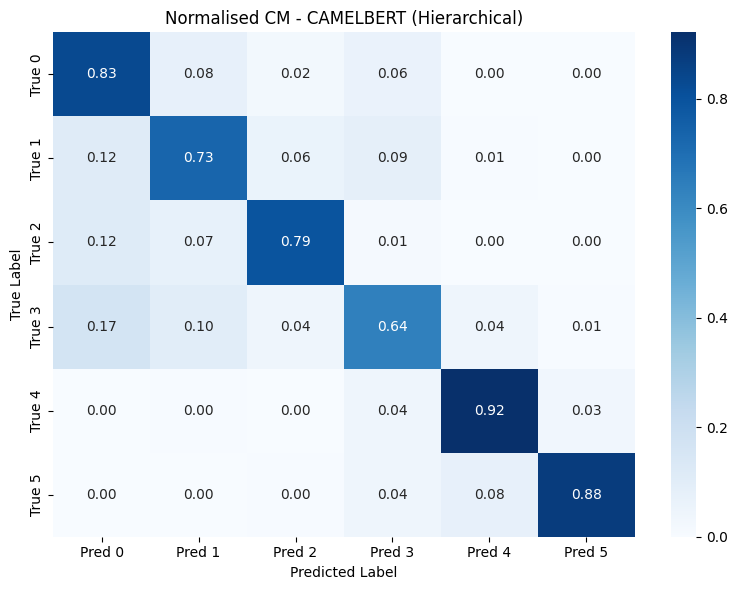

In [17]:
def display_hierarchical_results(results, name):
    print(f"\n{'=' * 70}")
    print(f"RESULTS: {name.upper()} (Two-Stage Hierarchical)")
    print(f"{'=' * 70}")

    y_true = results["y_true"]
    y_pred = results["y_pred"]

    wf1 = f1_score(y_true, y_pred, average='weighted')


    print(f"Test Accuracy (6-class): {results['test_acc']:.4f}")
    print(f"QWK:                     {results['qwk']:.4f}")
    print(f"Weighted F1:             {results['weighted_f1']:.4f}")
    print(f"Coarse Accuracy:         {results['coarse_test_acc']:.4f}")
    print(f"Training Time:           {results['training_time']:.1f} min")

    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    print(f"Confusion Matrix:\n{cm}")

    # Normalised confusion matrix plot
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=[f"Pred {i}" for i in range(len(cm))],
                yticklabels=[f"True {i}" for i in range(len(cm))])
    plt.title(f"Normalised CM - {name.upper()} (Hierarchical)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"cm_hier_{name}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()


display_hierarchical_results(results, "camelbert")


In [18]:
print("\n" + "=" * 70)
print("FINAL RESULTS (Two-Stage Hierarchical CamelBERT)")
print("=" * 70)
print(f"  Accuracy (6-class): {results['test_acc']:.4f}")
print(f"  QWK:                {results['qwk']:.4f}")
print(f"  Weighted F1:        {results['weighted_f1']:.4f}")
print(f"  Coarse Accuracy:    {results['coarse_test_acc']:.4f}")
print(f"  Training Time:      {results['training_time']:.1f} min")



FINAL RESULTS (Two-Stage Hierarchical CamelBERT)
  Accuracy (6-class): 0.8015
  QWK:                0.8835
  Weighted F1:        0.8017
  Coarse Accuracy:    0.9183
  Training Time:      79.3 min
